# Типы локальных экономик: кластеризация МО

**Задача.** Разбить муниципальные образования на группы с похожей экономикой и дать каждой группе понятное название.

**Два прогона на одном каркасе.**

| Прогон | Что подаётся на вход | Зачем |
|---|---|---|
| **A** | только статичные признаки: отраслевая структура, демография, инфраструктура, география | проверить, различаются ли МО по устройству экономики |
| **B** | статичные признаки плюс помесячные траты | проверить, добавляет ли потребление что-то сверх статики |

**Результат.** Четыре типа: сырьевые районы, ядра агломераций, промышленные города, аграрная периферия. Разбор прогона с числами — в разделе 13.

**Главный раздел — 10, интерпретация.** Там три графика, по которым результат читается без погружения в методы: что разделяет МО, карта отличий типов и карточки типов.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import HDBSCAN, AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

## 0. Конфигурация

In [2]:
SEED = 42
FEATURES_PATH = Path('results/mo_features.csv')
COSTS_PATH = Path('data/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij_ru_1764079373653.parquet')
CATEGORIES = ['Здоровье', 'Общественное питание', 'Продовольствие', 'Маркетплейсы', 'Транспорт']

K_RANGE = range(2, 16)          # перебираемое число кластеров
K_NN = 15                       # соседей при построении сети
MIN_COVERAGE = 0.80             # признак берём, если он есть хотя бы у 80% МО
MIN_MO_COVERAGE = 0.50          # МО берём, если у него есть хотя бы половина признаков
# Признаки, которые нельзя подавать в кластеризацию:
# oktmo_region — это код региона, то есть идентификатор, а не свойство экономики;
# координаты центроида превращают типологию в разрезание карты по долготе;
# geo_is_region_center — флаг «центр региона», он почти совпадает с ответом
#   и сам задаёт один из типов. Признак перенесён из входных в проверочные
#   (раздел 10): центры должны выделиться из экономики сами, а флаг
#   показывает, насколько это совпало.
EXCLUDE_FEATURES = ['oktmo_region', 'geo_centroid_lat', 'geo_centroid_lon',
                    'geo_is_region_center']
CORR_LIMIT = 0.80               # выше этой корреляции признаки считаем дублями
PROTECT = ['населен']           # эти признаки не выбрасываем: нужны для интерпретации
MAX_CLUSTER_SHARE = 0.80        # кластер больше 80% МО — вырожденное разбиение
# Порог в 1% требует не меньше 16 МО в кластере, и спектральный метод
# с Louvain выбывают целиком: они выделяют группы по 5–10 МО. При 0.5%
# в сравнении участвуют четыре метода из шести
MIN_CLUSTER_SHARE = 0.005       # кластер меньше 0.5% МО — тоже
MAX_NOISE_SHARE = 0.20          # больше 20% в шуме — тоже
N_BOOT = 10                     # повторов при проверке устойчивости
LAMBDA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]   # вес рядов в комбинированном расстоянии

OUT = Path('results'); OUT.mkdir(exist_ok=True)
np.random.seed(SEED)

# Палитра: синий, оранжевый, бирюзовый, жёлтый, розовый, зелёный, фиолетовый, красный.
# Порядок фиксирован, цвета не перебираются по кругу.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})

## 1. Методология простым языком

Шесть шагов, каждый отвечает на свой вопрос.

1. **Признаки.** Чем описываем МО. Берём то, что собрано в `mo_features.csv`: отраслевая структура, уровень жизни, демография, инфраструктура, положение в пространстве.
2. **Подготовка.** Приводим признаки к сопоставимому виду и выбрасываем дубли. Если одна и та же сторона жизни описана пятью похожими показателями, она войдёт в расстояние впятеро сильнее остальных.
3. **Расстояние.** Насколько два МО непохожи. Это одно число на пару МО.
4. **Сеть.** Соединяем каждое МО с его ближайшими соседями. Получается карта экономической близости, по которой работают графовые методы и считается модулярность.
5. **Кластеризация.** Шесть методов, число кластеров от 2 до 15.
6. **Выбор.** Для каждого варианта считаем четыре индекса качества и устойчивость. Побеждает тот, что хорош по сумме мест.

Итог — таблица «МО → тип экономики» и описание каждого типа.

## 2. Данные

In [3]:
features_raw = pd.read_csv(FEATURES_PATH, dtype={'oktmo': str}).set_index('oktmo')
print(f'Статичных признаков: {features_raw.shape[1]}, МО: {len(features_raw)}')
display(features_raw.head(3))

Статичных признаков: 80, МО: 1855


,mo,oktmo_region,mo_norm,rs_население_среднегод,rs_организации,rs_ип,rs_зарплата_крупные,rs_инвестиции_на_душу,rs_продтовары_объем,rs_средства_размещения,rs_площадь_земель,rs_улицы,rs_дороги_плохие_доля,rs_жилье_на_жителя,rs_жилье_ввод_на_жителя,rs_жилье_благоустр,rs_лпу,rs_детсады_охват,rs_доля_своих_доходов,rs_расходы_на_омсу,rs_коэф_рождаемости,rs_коэф_смертности,rs_коэф_естприроста,rs_организации_на_1000,rs_ип_на_1000,rs_лпу_на_1000,rs_средства_размещения_на_1000,rs_продтовары_объем_на_1000,rs_улицы_на_1000,rs_плотность_на_км2,...,"rs_работники_доля_Раздел G Торговля оптовая и розничная, ремонт автотранспортных средств и мотоциклов",rs_работники_доля_Раздел I Деятельность гостиниц и предприятий общественного питания,rs_работники_доля_Раздел J Деятельность в области информации и связи,rs_работники_доля_Раздел K Деятельность финансовая и страховая,rs_работники_доля_Раздел L Деятельность по операциям с недвижимым имуществом,"rs_работники_доля_Раздел M Деятельность профессиональная, научная и техническая",rs_работники_доля_Раздел N Деятельность административная и сопутствующие дополнительные услуги,"rs_работники_доля_Раздел O Государственное управление и обеспечение военной безопасности, социальное обеспечение",rs_работники_доля_Раздел P Образование,rs_работники_доля_Раздел Q Деятельность в области здравоохранения и социальных услуг,"rs_работники_доля_Раздел R Деятельность в области культуры, спорта, организации досуга и развлечений","rs_работники_доля_Раздел А Сельское, лесное хозяйство, охота, рыболовство и рыбоводство",rs_работники_доля_Раздел В Добыча полезных ископаемых,"rs_работники_доля_Раздел Е Водоснабжение, водоотведение, организация сбора и утилизация отходов, деятельность по ликвидации загрязнений",rs_работники_доля_Раздел Н Транспортировка и хранение,rs_работники_доля_нераскрыто,geo_area_km2,geo_centroid_lat,geo_centroid_lon,geo_compactness,geo_neighbors,geo_population,geo_density_per_km2,geo_dist_to_city_100k_km,geo_dist_to_city_500k_km,geo_is_suburb,geo_dist_to_region_center_km,geo_is_region_center,geo_pop_within_100km,geo_market_potential
oktmo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
93605000,Бай-Тайгинский муниципальный район,93,бай тайгинский,10364.000,88.000,206.750,53825.100,190.500,270677.600,4.000,797210.900,115.100,89.000,11.500,0.160,8.090,6.000,59.900,26.800,10369.000,17.700,10.300,7.400,8.491,19.949,0.579,0.386,26117.098,11.106,1.300,...,0.000,0.000,0.000,0.000,0.000,0.046,0.000,0.125,0.612,0.000,0.035,0.000,0.000,0.000,0.000,0.183,7970.400,51.076,89.699,0.313,4,10364.000,1.300,312.242,479.989,0.000,310.344,0,29567.000,48489.227
97526000,Красночетайский муниципальный округ,97,красночетайский,13632.000,96.500,269.250,48898.000,1699.300,727159.600,NaN,69156.000,263.400,54.200,45.710,0.500,187.780,27.000,48.500,9.600,4225.600,6.300,20.100,-13.800,7.079,19.751,1.981,NaN,53342.107,19.322,19.712,...,0.036,0.000,0.000,0.012,0.000,0.033,0.000,0.131,0.328,0.090,0.036,0.000,0.000,0.000,0.000,0.262,687.200,55.669,46.114,0.243,4,13632.000,19.837,91.194,91.194,0.000,91.194,0,1089831.500,163331.704
42645000,Тербунский муниципальный район,42,тербунский,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1169.520,52.144,38.417,0.180,4,NaN,NaN,92.727,239.592,NaN,92.727,0,756522.333,138661.439


In [4]:
import sys
sys.path.insert(0, str(Path.cwd()))
from datasets import boundaries

BOUNDARIES_PATH = Path('data/Municipalities_Russia_2025.geojson')
SOURCE_CRS = 3857                        # система координат файла границ

costs = pd.read_parquet(COSTS_PATH) if COSTS_PATH.suffix == '.parquet' else pd.read_csv(COSTS_PATH)
costs['period'] = pd.to_datetime(costs['period'])

mo_boundaries = boundaries.load(BOUNDARIES_PATH, crs=SOURCE_CRS)
mapping = boundaries.match(mo_boundaries, costs['mo'])
costs = (costs.drop(columns=['oktmo'], errors='ignore')
         .merge(mapping[['mo', 'oktmo']], on='mo', how='inner'))
print(f'Строк трат после сопоставления: {len(costs)}, МО: {costs["mo"].nunique()}')

panel = (costs[costs['category_15'].isin(CATEGORIES)]
         .pivot_table(index=['oktmo', 'period'], columns='category_15', values='value', aggfunc='mean')
         .reindex(columns=CATEGORIES).sort_index())

# В анализ берём МО с полной историей и без пропусков по категориям
months = panel.groupby(level='oktmo').size()
full = months[months == months.max()].index
no_gaps = ~panel.isna().any(axis=1).groupby(level='oktmo').any()
good = [mo for mo in full if no_gaps[mo]]
panel = panel.loc[good]

periods = panel.index.get_level_values('period').unique().sort_values()
ts_mo = panel.index.get_level_values('oktmo').unique()
X_ts = panel.values.reshape(len(ts_mo), len(periods), len(CATEGORIES))
print(f'Ряды: {len(ts_mo)} МО × {len(periods)} мес. ({periods.min():%Y-%m} … {periods.max():%Y-%m})')
print(f'Пересечение со статичными признаками: {len(set(ts_mo) & set(features_raw.index))} МО')

Один ОКТМО у нескольких объектов: 9 строк, они объединены
Границы: 2666 МО
МО в тратах: 2118
  сопоставлено: 1855
  отброшено как неоднозначные: 226 (сокращённых названий: 129)
  нет в границах: 37

Примеры отброшенных:
                                                                              mo      short_name
 внутригородская территория города федерального значения муниципальный округ № 7                
внутригородская территория города федерального значения муниципальный округ № 54                
внутригородская территория города федерального значения муниципальный округ № 65                
внутригородская территория города федерального значения муниципальный округ № 78                
внутригородская территория города федерального значения муниципальный округ № 15                
внутригородская территория города федерального значения муниципальный округ № 72                
внутригородская территория города федерального значения муниципальный округ № 21                
    

## 3. Подготовка признаков

Три шага, каждый со своей причиной.

**Отбор по полноте — с двух сторон.** По столбцам: признак, который есть у половины МО, пришлось бы заполнять, создавая искусственное сходство, поэтому берём только те, что есть хотя бы у 80% МО. По строкам: МО, у которого заполнено меньше половины признаков, тоже выбрасываем. Второе не менее важно первого: у части МО данных Росстата нет вовсе, и после заполнения медианой они стали бы одинаковыми «средними МО» и склеились в кластер, которого в реальности нет. Оставшиеся редкие пропуски заполняем медианой.

**Логарифм для скошенных.** Площадь, население, инвестиции распределены так, что несколько МО на порядок больше остальных. Без логарифма такой признак один определяет расстояние: разница между Москвой и всеми остальными перевесит все прочие различия. Логарифмируем неотрицательные признаки с коэффициентом асимметрии выше 2.

**Снятие дублирования.** Убираем признаки попарно: пока есть пара с корреляцией выше 0,8, выбрасываем того из двоих, кто в среднем сильнее связан со всеми остальными. Важно убирать именно попарно, а не группами связанных: если A похож на B, B на C, а C на D, то A и D могут быть совсем разными, и схлопывание всей цепочки в один признак потеряло бы содержательные различия.

**Масштабирование.** Вычитаем среднее и делим на стандартное отклонение. Масштабирование по межквартильному размаху (RobustScaler) для этих данных не подходит: отраслевые доли сильно разрежены — у доли сельского хозяйства в отгрузке три четверти МО имеют почти ноль, — межквартильный размах получается микроскопическим, и деление на него раздувает признак в сотни раз. Один такой признак затем определяет всё расстояние. Стандартное отклонение у разреженного признака ведёт себя нормально. После масштабирования печатается предупреждение, если какой-то признак всё равно заметно шире остальных.

In [5]:
def select_by_coverage(table, min_coverage=MIN_COVERAGE, exclude=EXCLUDE_FEATURES):
    # Только числовые признаки с достаточным покрытием, без идентификаторов
    numeric = table.select_dtypes('number').drop(columns=exclude, errors='ignore')
    dropped_id = [c for c in exclude if c in table.columns]
    if dropped_id:
        print(f'Исключены как не-признаки: {", ".join(dropped_id)}')

    coverage = numeric.notna().mean()
    kept = coverage[coverage >= min_coverage].index
    thrown = coverage[coverage < min_coverage].sort_values()
    print(f'Признаков: было {numeric.shape[1]}, осталось {len(kept)} '
          f'(отброшено {len(thrown)} с покрытием ниже {min_coverage:.0%})')
    if len(thrown):
        # Важно посмотреть, что именно потерялось: если ушла отраслевая структура,
        # кластеризовать будет нечем, кроме географии и демографии
        print('Отброшенные признаки и их покрытие:')
        display(thrown.to_frame('доля МО со значением'))
    return numeric[kept]


def is_share(column):
    # Признак-доля: уже ограничен отрезком 0–1, в логарифме и не нуждается
    return column.min() >= 0 and column.max() <= 1


def log_skewed(table, skew_limit=2.0):
    # Логарифмируем неотрицательные признаки с длинным правым хвостом.
    # Доли не трогаем: они и так ограничены, а логарифм только мешает читать профиль
    out = table.copy()
    skewed = [c for c in table.columns
              if not is_share(table[c]) and table[c].min() >= 0
              and stats.skew(table[c].dropna()) > skew_limit]
    out[skewed] = np.log1p(out[skewed])
    print(f'Логарифмировано скошенных признаков: {len(skewed)} '
          f'(доли пропущены: их {sum(is_share(table[c]) for c in table.columns)})')
    return out


def scale(table):
    # Привести признаки к сопоставимому разбросу.
    #
    # Масштабирование по межквартильному размаху (RobustScaler) здесь ломается.
    # Отраслевые доли сильно разрежены: у доли сельского хозяйства в отгрузке
    # три четверти МО имеют почти ноль, размах получается микроскопическим,
    # и деление на него раздувает признак в сотни раз — один такой признак
    # начинает определять всё расстояние.
    #
    # StandardScaler делит на стандартное отклонение, которое у разреженного
    # признака ведёт себя нормально.
    constant = [c for c in table.columns if table[c].nunique() <= 1]
    if constant:
        print(f'Отброшено признаков без разброса: {len(constant)} — {", ".join(constant[:5])}')
        table = table.drop(columns=constant)

    scaled = pd.DataFrame(StandardScaler().fit_transform(table),
                          index=table.index, columns=table.columns)

    # Сигнализация: если какой-то признак после масштабирования всё равно
    # на порядок шире остальных, он перетянет расстояние на себя
    span = (scaled.max() - scaled.min()).sort_values(ascending=False)
    if span.iloc[0] > 4 * span.median():
        print('Внимание: размах этих признаков заметно больше остальных '
              f'(медиана {span.median():.1f}):')
        display(span.head(5).to_frame('размах после масштабирования'))
    return scaled


def drop_correlated(table, limit=CORR_LIMIT, protect=PROTECT):
    # Попарное удаление: пока есть пара сильнее limit, убираем того из двоих,
    # кто в среднем сильнее связан с остальными. Защищённые признаки остаются
    # в любом случае — без населения нечем проверять шкалу размера города
    corr = table.corr(method='spearman').abs()
    corr = corr.where(~np.eye(len(corr), dtype=bool), 0.0)   # обнулить диагональ
    removed = []
    while len(corr) > 1 and corr.to_numpy().max() >= limit:
        flat = corr.to_numpy().argmax()
        i, j = divmod(flat, corr.shape[1])
        a, b = corr.index[i], corr.columns[j]
        safe = lambda name: any(word in name.lower() for word in protect)
        if safe(a) and not safe(b):
            loser = b
        elif safe(b) and not safe(a):
            loser = a
        else:
            loser = a if corr[a].mean() >= corr[b].mean() else b
        removed.append({'убран': loser, 'дублирует': b if loser == a else a,
                        'корреляция': round(corr.loc[a, b], 2)})
        corr = corr.drop(index=loser, columns=loser)
    if removed:
        print(f'Убрано дублирующих признаков: {len(removed)}')
        display(pd.DataFrame(removed))
    return table[list(corr.index)]

In [6]:
selected = select_by_coverage(features_raw)

# Отбрасываем МО, по которым почти нет данных. Без этого им проставится медиана
# по каждому признаку, все они станут одинаковыми «средними МО» и склеятся
# в искусственный кластер, которого в реальности нет
filled = selected.notna().mean(axis=1)
poor = filled < MIN_MO_COVERAGE
if poor.any():
    print(f'Отброшено МО с заполненностью ниже {MIN_MO_COVERAGE:.0%}: {poor.sum()} из {len(selected)}')
    display(filled[poor].sort_values().head(5).to_frame('доля заполненных признаков'))
selected = selected[~poor]
selected = selected.fillna(selected.median())
selected = log_skewed(selected)
selected = drop_correlated(selected)
print(f'\nИтого признаков для кластеризации: {selected.shape[1]}')

X_static = scale(selected)
display(X_static.describe().T[['mean', '50%', 'std', 'min', 'max']].head(10))

Исключены как не-признаки: oktmo_region, geo_centroid_lat, geo_centroid_lon, geo_is_region_center
Признаков: было 74, осталось 62 (отброшено 12 с покрытием ниже 80%)
Отброшенные признаки и их покрытие:


,доля МО со значением
rs_жилье_благоустр,0.715
rs_детсады_охват,0.720
rs_дороги_плохие_доля,0.726
rs_доля_своих_доходов,0.729
rs_расходы_на_омсу,0.729
rs_жилье_на_жителя,0.740
rs_жилье_ввод_на_жителя,0.748
rs_средства_размещения_на_1000,0.776
rs_улицы_на_1000,0.779
rs_лпу_на_1000,0.780


Отброшено МО с заполненностью ниже 50%: 286 из 1855


,доля заполненных признаков
oktmo,
25618000,0.129
42652000,0.129
25646000,0.129
52609000,0.129
76625000,0.129


Логарифмировано скошенных признаков: 21 (доли пропущены: их 38)
Убрано дублирующих признаков: 10


,убран,дублирует,корреляция
0,geo_population,rs_население_среднегод,1.000
1,rs_плотность_на_км2,geo_density_per_km2,0.990
2,rs_площадь_земель,geo_area_km2,0.980
3,rs_ип,rs_население_среднегод,0.940
4,geo_pop_within_100km,geo_dist_to_city_100k_km,0.910
5,rs_организации,rs_население_среднегод,0.910
6,geo_density_per_km2,geo_area_km2,0.890
7,rs_продтовары_объем,rs_население_среднегод,0.890
8,rs_коэф_смертности,rs_коэф_естприроста,0.880
9,rs_работники_доля_Раздел В Добыча полезных иск...,rs_отгружено_доля_Раздел В Добыча полезных иск...,0.820



Итого признаков для кластеризации: 52


,mean,50%,std,min,max
rs_население_среднегод,-0.000,-0.160,1.000,-2.621,3.617
rs_зарплата_крупные,0.000,-0.241,1.000,-2.156,3.999
rs_инвестиции_на_душу,0.000,0.029,1.000,-5.187,3.930
rs_улицы,0.000,0.144,1.000,-3.987,2.625
rs_лпу,0.000,-0.016,1.000,-2.675,4.672
rs_коэф_рождаемости,-0.000,-0.032,1.000,-3.659,7.745
rs_коэф_естприроста,-0.000,-0.074,1.000,-2.798,12.524
rs_организации_на_1000,0.000,-0.233,1.000,-4.394,4.928
rs_ип_на_1000,-0.000,-0.139,1.000,-4.234,5.763
rs_отгружено_доля_Раздел C Обрабатывающие производства,0.000,-0.627,1.000,-0.627,2.595


## 4. Расстояние и сеть

**Расстояние** — евклидово по подготовленным признакам: два МО тем ближе, чем ближе их значения по всем признакам сразу.

**Сеть.** Ребро ставится между МО, которые входят в списки ближайших соседей друг друга (взаимные k ближайших соседей). Вес ребра тем больше, чем МО ближе.

К этим рёбрам добавляется **минимальное остовное дерево** — самый короткий набор связей, соединяющий все МО. Без него нетипичные МО остаются вообще без рёбер, граф рассыпается на десятки компонент, и графовые методы выдают непригодные разбиения, то есть просто не проверяются. Отчёт ниже показывает оба варианта при разных k, чтобы эффект был виден.

In [7]:
def knn_graph(D, k=K_NN, mutual=True, connect=True):
    # Матрица весов сети: взаимные k ближайших соседей плюс остовное дерево для связности
    n = len(D)
    tree = minimum_spanning_tree(D).toarray() > 0 if connect else np.zeros((n, n), bool)
    D_work = D.copy()
    np.fill_diagonal(D_work, np.inf)
    nn = np.argsort(D_work, axis=1)[:, :k]
    A = np.zeros((n, n), bool)
    A[np.arange(n)[:, None], nn] = True
    A = (A & A.T) if mutual else (A | A.T)
    A = A | tree | tree.T
    sigma = np.median(D_work[np.arange(n)[:, None], nn]) + 1e-12
    return np.where(A, np.exp(-(D / sigma) ** 2), 0.0)


def modularity(W, labels):
    # Модулярность разбиения на взвешенной сети (индекс MQ)
    two_m = W.sum()
    if two_m == 0:
        return np.nan
    return sum(W[np.ix_(labels == c, labels == c)].sum() / two_m
               - (W[labels == c].sum() / two_m) ** 2 for c in np.unique(labels))


def graph_report(D, k_values=(5, 10, 15, 30, 50)):
    rows = []
    for k in k_values:
        for rule, W in [('mutual kNN', knn_graph(D, k, connect=False)),
                        ('mutual kNN + дерево', knn_graph(D, k))]:
            components = nx.number_connected_components(nx.from_numpy_array(W))
            degree = (W > 0).sum(axis=1)
            rows.append({'правило': rule, 'k': k, 'рёбер': int((W > 0).sum() // 2),
                         'изолированных МО': int((degree == 0).sum()), 'компонент': components})
    return pd.DataFrame(rows)


D_static = squareform(pdist(X_static.values))
W_static = knn_graph(D_static)
display(graph_report(D_static))

,правило,k,рёбер,изолированных МО,компонент
0,mutual kNN,5,1598,292,406
1,mutual kNN + дерево,5,2245,0,1
2,mutual kNN,10,3262,130,161
3,mutual kNN + дерево,10,3664,0,1
4,mutual kNN,15,4937,75,94
5,mutual kNN + дерево,15,5232,0,1
6,mutual kNN,30,10092,25,34
7,mutual kNN + дерево,30,10272,0,1
8,mutual kNN,50,17108,13,18
9,mutual kNN + дерево,50,17229,0,1


## 5. Методы кластеризации

Шесть методов из трёх семейств: они по-разному понимают, что такое кластер. Согласие между ними — довод в пользу того, что найденная структура принадлежит самим данным.

| Метод | Идея | Что считает кластером |
|---|---|---|
| k-means | минимизирует разброс вокруг центров | компактное облако |
| k-medoids | то же, но центр — реальное МО | компактное облако, устойчив к выбросам |
| агломеративный (Ward) | последовательно сливает ближайшие группы | вложенную структуру |
| спектральный | разрезает сеть по слабым связям | область, слабо связанную с остальными |
| Louvain | ищет сообщества в сети | плотно связанную группу узлов |
| HDBSCAN | ищет сгущения | область высокой плотности, остальное помечает шумом |

In [8]:
def kmedoids(D, k, seed=SEED, n_iter=100):
    # Простой k-medoids: старт как в k-means++, затем «назначить → обновить медоиды»
    rng = np.random.default_rng(seed)
    medoids = [rng.integers(len(D))]
    for _ in range(k - 1):
        far = D[:, medoids].min(axis=1) ** 2
        medoids.append(rng.choice(len(D), p=far / far.sum()))
    medoids = np.array(medoids)
    for _ in range(n_iter):
        labels = D[:, medoids].argmin(axis=1)
        new = medoids.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members):
                new[c] = members[D[np.ix_(members, members)].sum(axis=1).argmin()]
        if np.array_equal(new, medoids):
            break
        medoids = new
    return D[:, medoids].argmin(axis=1)


def louvain(W, resolution=1.0, seed=SEED):
    communities = nx.community.louvain_communities(nx.from_numpy_array(W), weight='weight',
                                                   resolution=resolution, seed=seed)
    labels = np.empty(len(W), dtype=int)
    for c, nodes in enumerate(communities):
        labels[list(nodes)] = c
    return labels


def run_method(method, param, D, X, seed=SEED):
    # Одна точка входа. param — число кластеров, для louvain — разрешение,
    # для hdbscan — минимальный размер кластера
    param = float(param) if method == 'louvain' else int(param)
    if method == 'kmeans':
        return KMeans(param, n_init=10, random_state=seed).fit_predict(X)
    if method == 'kmedoids':
        return kmedoids(D, param, seed)
    if method == 'ward':
        return AgglomerativeClustering(n_clusters=param, linkage='ward').fit_predict(X)
    if method == 'spectral':
        return SpectralClustering(n_clusters=param, affinity='precomputed',
                                  random_state=seed).fit_predict(knn_graph(D))
    if method == 'louvain':
        return louvain(knn_graph(D), resolution=param, seed=seed)
    if method == 'hdbscan':
        return HDBSCAN(min_cluster_size=param, metric='precomputed', copy=True).fit_predict(D)
    raise ValueError(method)


LOUVAIN_RES = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
HDBSCAN_SIZES = [10, 20, 40]


def all_configs():
    configs = [(m, k) for m in ['kmeans', 'kmedoids', 'ward', 'spectral'] for k in K_RANGE]
    configs += [('louvain', r) for r in LOUVAIN_RES]
    configs += [('hdbscan', s) for s in HDBSCAN_SIZES]
    return configs

## 6. Оценка качества

Четыре индекса. Все они считаются без «правильного ответа», только по самим данным: хорошее разбиение — то, где внутри кластера объекты похожи, а между кластерами различаются.

| Индекс | Простыми словами | Лучше, когда |
|---|---|---|
| **SW**, силуэт | насколько каждое МО ближе к своему кластеру, чем к ближайшему чужому | больше (от −1 до 1) |
| **CH**, Калинский–Харабаш | разброс между центрами кластеров, делённый на разброс внутри них | больше |
| **S_Dbw** | рыхлость кластеров плюс плотность точек в промежутке между ними | меньше |
| **MQ**, модулярность | насколько связи внутри кластеров плотнее, чем в случайной сети | больше |

AVI и AVU не используем: общепринятых формул у них нет, а в методичке расшифровки не дали.

**Пятый критерий — устойчивость.** Убираем 20% МО, кластеризуем заново, сравниваем с исходным разбиением на оставшихся МО через ARI (1 — полное совпадение, 0 — на уровне случайного). На этих данных устойчивость оказалась информативнее всех четырёх индексов: она различает разбиения, у которых индексы почти совпадают.

**Вырожденные разбиения исключаются:** кластер больше 80% МО, кластер меньше 0.5% МО или больше 20% МО в шуме. Нижний порог подобран так, чтобы в сравнении оставались методы, выделяющие мелкие группы: при 1% спектральный метод и Louvain выбывали целиком. Порог по шуму нужен для HDBSCAN: его индексы считаются только по неотнесённым к шуму точкам, поэтому разбиение, где в шум ушла большая часть выборки, выглядит завышенно хорошим.

In [9]:
def s_dbw(X, labels):
    # S_Dbw: рыхлость кластеров + плотность между ними (Halkidi, Vazirgiannis, 2001)
    ids = np.unique(labels)
    centers = np.array([X[labels == c].mean(axis=0) for c in ids])
    sigmas = np.array([np.linalg.norm(X[labels == c].var(axis=0)) for c in ids])
    scat = sigmas.mean() / np.linalg.norm(X.var(axis=0))
    stdev = np.sqrt(sigmas.sum()) / len(ids)

    def density(point, mask):
        return np.sum(np.linalg.norm(X[mask] - point, axis=1) <= stdev)

    total, pairs = 0.0, 0
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            mask = np.isin(labels, [ids[i], ids[j]])
            middle = density((centers[i] + centers[j]) / 2, mask)
            total += middle / max(density(centers[i], mask), density(centers[j], mask), 1)
            pairs += 1
    return scat + total / max(pairs, 1)


METRICS = {'SW': True, 'CH': True, 'S_Dbw': False, 'MQ': True}   # True = больше лучше


def evaluate(labels, D, X, W):
    keep = labels >= 0
    lab = labels[keep]
    sizes = np.unique(lab, return_counts=True)[1] / max(len(labels), 1)
    row = {'k_факт': len(sizes), 'шум': 1 - keep.mean(),
           'мин_доля': sizes.min() if len(sizes) else np.nan,
           'макс_доля': sizes.max() if len(sizes) else np.nan}
    if len(sizes) < 2:
        return row
    D_keep = D if keep.all() else D[np.ix_(keep, keep)]
    row['SW'] = silhouette_score(D_keep, lab, metric='precomputed')
    row['CH'] = calinski_harabasz_score(X[keep], lab)
    row['S_Dbw'] = s_dbw(X[keep], lab)
    row['MQ'] = modularity(W, labels)
    return row


def stability(method, param, D, X, n_boot=N_BOOT, frac=0.8, seed=SEED):
    full = run_method(method, param, D, X, seed)
    rng = np.random.default_rng(seed)
    scores = []
    for b in range(n_boot):
        idx = np.sort(rng.choice(len(D), int(frac * len(D)), replace=False))
        labels = run_method(method, param, D[np.ix_(idx, idx)], X[idx], seed=seed + b + 1)
        scores.append(adjusted_rand_score(full[idx], labels))
    return float(np.mean(scores))

In [10]:
def sweep(D, X, W, name, with_stability=True):
    # Перебор всех методов и параметров с расчётом индексов
    partitions, rows = {}, []
    for method, param in all_configs():
        t0 = time.time()
        labels = run_method(method, param, D, X)
        partitions[(method, param)] = labels
        rows.append({'метод': method, 'параметр': param, 'сек': time.time() - t0,
                     **evaluate(labels, D, X, W)})
    table = pd.DataFrame(rows)
    table['вырожденное'] = ((table['макс_доля'] > MAX_CLUSTER_SHARE)
                            | (table['мин_доля'] < MIN_CLUSTER_SHARE)
                            | (table['шум'] > MAX_NOISE_SHARE))
    print(f'[{name}] конфигураций {len(table)}, вырожденных {table["вырожденное"].sum()}')
    print(table.groupby('метод')['вырожденное'].mean().to_frame('доля вырожденных').T.to_string())

    if with_stability:
        good = table[~table['вырожденное']]
        table['устойчивость'] = np.nan
        for i, row in good.iterrows():
            table.loc[i, 'устойчивость'] = stability(row['метод'], row['параметр'], D, X)
    return partitions, table


def best_per_method(table):
    # Лучший параметр каждого метода по сумме мест во всех индексах и устойчивости
    good = table[~table['вырожденное']].dropna(subset=list(METRICS))
    rows = []
    for method, group in good.groupby('метод'):
        score = sum(group[m].rank(ascending=not higher) for m, higher in METRICS.items())
        if 'устойчивость' in group:
            score = score + group['устойчивость'].rank(ascending=False)
        rows.append(group.loc[score.idxmin()])
    return pd.DataFrame(rows).reset_index(drop=True)

In [11]:
parts_A, table_A = sweep(D_static, X_static.values, W_static, 'A: статика')
best_A = best_per_method(table_A)
display(best_A[['метод', 'параметр', 'k_факт', 'шум', *METRICS, 'устойчивость', 'сек']])

[A: статика] конфигураций 65, вырожденных 29
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.214     0.000    0.833     1.000 0.286


,метод,параметр,k_факт,шум,SW,CH,S_Dbw,MQ,устойчивость,сек
0,kmeans,4.000,4,0.000,0.121,155.687,1.384,0.468,0.957,0.063
1,kmedoids,6.000,6,0.000,0.102,104.847,1.290,0.471,0.387,0.008
2,louvain,0.500,11,0.000,0.058,66.956,1.343,0.757,0.652,0.514
3,ward,4.000,4,0.000,0.105,126.683,1.477,0.531,0.715,0.038


### Как индексы ведут себя при разном числе кластеров

Ищем k, на котором несколько индексов одновременно дают пик (SW, CH, MQ) или провал (S_Dbw). Если кривые монотонны, выраженного числа кластеров в данных нет, и это сам по себе результат.

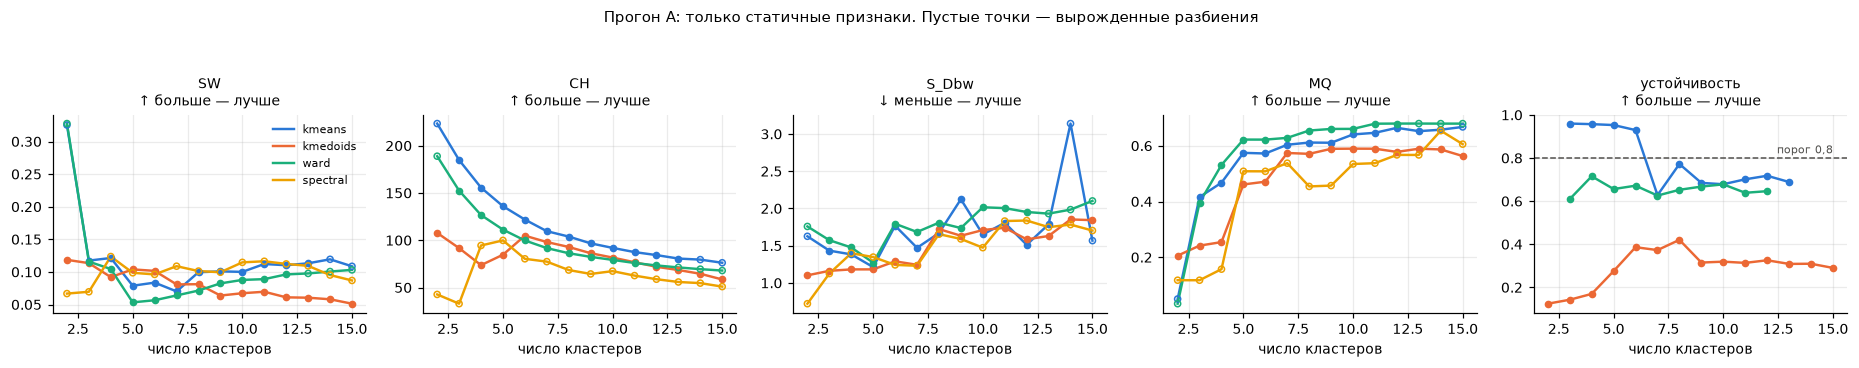

In [12]:
def plot_indices(table, title):
    methods = ['kmeans', 'kmedoids', 'ward', 'spectral']
    fig, axes = plt.subplots(1, len(METRICS) + 1, figsize=(17, 3.1))
    for color, method in zip(PALETTE, methods):
        g = table[(table['метод'] == method) & table['параметр'].between(2, 15)].sort_values('параметр')
        if g.empty:
            continue
        for ax, metric in zip(axes, [*METRICS, 'устойчивость']):
            if metric not in g:
                continue
            ok = ~g['вырожденное']
            ax.plot(g['параметр'], g[metric], color=color, lw=1.6, label=method, zorder=2)
            ax.scatter(g['параметр'][ok], g[metric][ok], color=color, s=16, zorder=3)
            ax.scatter(g['параметр'][~ok], g[metric][~ok], facecolors='none',
                       edgecolors=color, s=16, zorder=3)
    for ax, metric in zip(axes, [*METRICS, 'устойчивость']):
        arrow = '↑ больше — лучше' if METRICS.get(metric, True) else '↓ меньше — лучше'
        ax.set_title(f'{metric}\n{arrow}', fontsize=9)
        ax.set_xlabel('число кластеров')
    axes[-1].axhline(0.8, color='#52514e', ls='--', lw=1)
    axes[-1].text(K_RANGE.stop - 1, 0.81, 'порог 0,8', ha='right', va='bottom', fontsize=7, color='#52514e')
    axes[0].legend(fontsize=7, frameon=False)
    fig.suptitle(f'{title}. Пустые точки — вырожденные разбиения', y=1.06, fontsize=10)
    plt.tight_layout(); plt.show()


plot_indices(table_A, 'Прогон A: только статичные признаки')

## 7. Прогон B: добавляем траты

Два способа, оба простые.

**B1. Признаки из рядов.** Из помесячных трат считаем уровень, доли категорий, годовой тренд, амплитуду сезонности и волатильность — и дописываем их к статичным признакам. Дальше работает тот же каркас.

**B2. Комбинированное расстояние.** $d = \lambda\,d_{\text{ряды}} + (1-\lambda)\,d_{\text{атрибуты}}$, где расстояние по рядам — корреляционное: два МО близки, если синхронно отклоняются от общероссийской динамики. Вычитание среднего по стране обязательно, иначе общая сезонность и инфляция сделают похожими вообще все МО.

При $\lambda = 0$ получается прогон A, при $\lambda = 1$ — кластеризация только по динамике трат. Сетка по λ показывает, есть ли между краями что-то лучше обоих.

**Важно, как читать таблицу по λ.** Силуэт, CH и S_Dbw считаются в геометрии своей меры расстояния, поэтому **сравнивать их между разными λ нельзя**: рост силуэта при λ = 1 говорит о другом устройстве пространства, а качество разбиения при этом может быть любым. Между собой λ сравниваются по двум величинам, которые от геометрии не зависят: **устойчивость** и **ARI с λ = 0**, показывающий, насколько сильно добавление рядов меняет состав групп.

DTW не берём: на этих рядах он совпал с евклидовым расстоянием на 96% ближайших соседей и считался в сотни раз дольше.

In [13]:
def ts_features(X, mo_index, categories=CATEGORIES):
    # Признаки из многомерного ряда трат: уровень, структура, тренд, сезонность, волатильность
    X_log = np.log1p(X)
    total = X.sum(axis=2)
    shares = X / np.where(total == 0, 1, total)[:, :, None]
    t = np.arange(X.shape[1])

    out = {'траты_уровень': np.log1p(total).mean(axis=1)}
    for c, name in enumerate(categories):
        out[f'траты_доля_{name}'] = shares[:, :, c].mean(axis=1)
    out['траты_тренд'] = np.polyfit(t, np.log1p(total).T, 1)[0] * 12
    out['траты_волатильность'] = np.diff(np.log1p(total), axis=1).std(axis=1)
    out['траты_сезонность'] = total.max(axis=1) / np.where(total.min(axis=1) == 0, 1, total.min(axis=1))
    return pd.DataFrame(out, index=mo_index)


def correlation_distance(X, mo_index):
    # Расстояние по синхронности: 1 - средняя по категориям корреляция отклонений от среднего по стране
    deviation = np.log1p(X) - np.log1p(X).mean(axis=0, keepdims=True)
    total = np.zeros((len(X), len(X)))
    for c in range(X.shape[2]):
        A = deviation[:, :, c]
        A = (A - A.mean(axis=1, keepdims=True)) / (A.std(axis=1, keepdims=True) + 1e-9)
        total += A @ A.T / A.shape[1]
    D = 1 - total / X.shape[2]
    D = (D + D.T) / 2
    np.fill_diagonal(D, 0)
    return pd.DataFrame(np.clip(D, 0, None), index=mo_index, columns=mo_index)


# Общие МО: только для них можно сравнивать прогоны A и B
common = sorted(set(X_static.index) & set(ts_mo))
ts_pos = [list(ts_mo).index(mo) for mo in common]
X_ts_common = X_ts[ts_pos]

F_ts = ts_features(X_ts_common, pd.Index(common, name='oktmo'))
X_static_common = X_static.loc[common]
print(f'Общих МО: {len(common)}, признаков из рядов: {F_ts.shape[1]}')
display(F_ts.describe().T[['mean', '50%', 'max']])

Общих МО: 1433, признаков из рядов: 9


,mean,50%,max
траты_уровень,9.878,9.819,10.582
траты_доля_Здоровье,0.070,0.068,0.120
траты_доля_Общественное питание,0.052,0.039,0.189
траты_доля_Продовольствие,0.606,0.617,0.818
траты_доля_Маркетплейсы,0.188,0.187,0.357
траты_доля_Транспорт,0.084,0.079,0.173
траты_тренд,0.182,0.188,0.363
траты_волатильность,0.085,0.082,0.180
траты_сезонность,1.656,1.673,2.377


In [14]:
# B1: статика + признаки из рядов
F_ts_prepared = log_skewed(F_ts)
combined = pd.concat([X_static_common, scale(F_ts_prepared)], axis=1)
X_B1 = drop_correlated(combined)
D_B1 = squareform(pdist(X_B1.values))
W_B1 = knn_graph(D_B1)

parts_B1, table_B1 = sweep(D_B1, X_B1.values, W_B1, 'B1: статика + признаки рядов')
best_B1 = best_per_method(table_B1)
display(best_B1[['метод', 'параметр', 'k_факт', *METRICS, 'устойчивость']])

Логарифмировано скошенных признаков: 0 (доли пропущены: их 6)
Убрано дублирующих признаков: 1


,убран,дублирует,корреляция
0,траты_тренд,траты_сезонность,0.880


[B1: статика + признаки рядов] конфигураций 65, вырожденных 35
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.357     0.071    1.000     1.000 0.429


,метод,параметр,k_факт,SW,CH,S_Dbw,MQ,устойчивость
0,kmeans,2.000,2,0.269,271.623,1.286,0.219,0.942
1,kmedoids,3.000,3,0.135,203.089,1.362,0.407,0.630
2,ward,4.000,4,0.102,141.474,1.336,0.544,0.659


In [15]:
# B2: комбинированное расстояние, перебор лямбды
D_corr = correlation_distance(X_ts_common, pd.Index(common)).values
D_attr = squareform(pdist(X_static_common.values))
scale = D_attr.max() or 1.0          # привести к одному масштабу перед смешиванием
D_attr_norm, D_corr_norm = D_attr / scale, D_corr / (D_corr.max() or 1.0)

rows, reference = [], None
for lam in LAMBDA_GRID:
    D_mix = (1 - lam) * D_attr_norm + lam * D_corr_norm
    W_mix = knn_graph(D_mix)
    parts_mix, table_mix = sweep(D_mix, X_static_common.values, W_mix,
                                 f'B2: λ={lam}', with_stability=False)
    best = best_per_method(table_mix)
    pick = best.loc[best['SW'].idxmax()]
    labels = parts_mix[(pick['метод'], pick['параметр'])]
    reference = labels if reference is None else reference
    rows.append({'λ': lam, 'метод': pick['метод'], 'k': pick['k_факт'],
                 'SW': pick['SW'], 'MQ': pick['MQ'],
                 'устойчивость': stability(pick['метод'], pick['параметр'],
                                           D_mix, X_static_common.values),
                 'ARI с λ=0': adjusted_rand_score(reference, labels)})

lambda_table = pd.DataFrame(rows)
print('\nКак меняется разбиение при разном весе рядов:')
display(lambda_table)

[B2: λ=0.0] конфигураций 65, вырожденных 43
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.143     0.857    1.000     1.000 0.429
[B2: λ=0.25] конфигураций 65, вырожденных 29
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.143     0.429    0.500     0.643 0.429
[B2: λ=0.5] конфигураций 65, вырожденных 20
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.143     0.000    0.000     0.643 0.429
[B2: λ=0.75] конфигураций 65, вырожденных 13
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.143     0.000    0.000     0.143 0.429
[B2: λ=1.0] конфигураций 65, вырожденных 13
метод             hdbscan  kmeans  kmedoids  louvain  spectral  ward
доля вырожденных    1.000   0.143     0.000    0.000     0.143 0.429

Как меняется разбиение при разном весе рядов:


,λ,метод,k,SW,MQ,устойчивость,ARI с λ=0
0,0.000,kmeans,4,0.131,0.490,0.952,1.000
1,0.250,spectral,2,0.235,0.416,0.785,0.330
2,0.500,kmedoids,3,0.184,0.427,0.664,0.146
3,0.750,kmedoids,4,0.221,0.458,0.574,0.189
4,1.000,kmedoids,3,0.266,0.429,0.588,0.203


## 8. Сравнение прогонов и методов

Два вопроса: какой метод лучше внутри прогона и дали ли траты выигрыш над чистой статикой.

Матрица ARI показывает, находят ли разные подходы одни и те же группы. Если независимые методы дают похожие разбиения, найденная структура принадлежит самим данным.

In [16]:
summary = pd.concat([best_A.assign(прогон='A: статика'),
                     best_B1.assign(прогон='B1: статика + ряды')], ignore_index=True)
display(summary[['прогон', 'метод', 'параметр', 'k_факт', *METRICS, 'устойчивость', 'сек']]
        .sort_values(['прогон', 'SW'], ascending=[True, False]))

,прогон,метод,параметр,k_факт,SW,CH,S_Dbw,MQ,устойчивость,сек
0,A: статика,kmeans,4.000,4,0.121,155.687,1.384,0.468,0.957,0.063
3,A: статика,ward,4.000,4,0.105,126.683,1.477,0.531,0.715,0.038
1,A: статика,kmedoids,6.000,6,0.102,104.847,1.290,0.471,0.387,0.008
2,A: статика,louvain,0.500,11,0.058,66.956,1.343,0.757,0.652,0.514
4,B1: статика + ряды,kmeans,2.000,2,0.269,271.623,1.286,0.219,0.942,0.049
5,B1: статика + ряды,kmedoids,3.000,3,0.135,203.089,1.362,0.407,0.630,0.006
6,B1: статика + ряды,ward,4.000,4,0.102,141.474,1.336,0.544,0.659,0.033


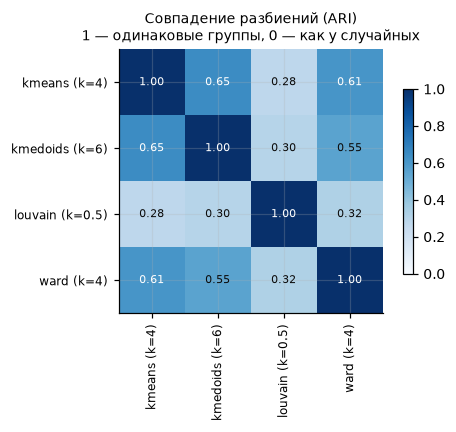

In [17]:
def ari_matrix(partitions, keys, labels_text):
    M = np.array([[adjusted_rand_score(partitions[a], partitions[b]) for b in keys] for a in keys])
    fig, ax = plt.subplots(figsize=(0.5 * len(keys) + 3, 0.5 * len(keys) + 2))
    im = ax.imshow(M, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(len(keys)), labels_text, rotation=90, fontsize=8)
    ax.set_yticks(range(len(keys)), labels_text, fontsize=8)
    for i in range(len(keys)):
        for j in range(len(keys)):
            ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if M[i, j] > 0.6 else '#0b0b0b')
    ax.set_title('Совпадение разбиений (ARI)\n1 — одинаковые группы, 0 — как у случайных', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()


keys_A = [(r['метод'], r['параметр']) for _, r in best_A.iterrows()]
ari_matrix(parts_A, keys_A, [f'{m} (k={p:g})' for m, p in keys_A])

## 9. Итоговое разбиение

Внутри прогона правило простое: среди невырожденных берём конфигурацию с лучшей суммой мест по четырём индексам и устойчивости.

Между прогонами A и B1 сравнение идёт **по устойчивости**. Наборы признаков у них разные, значит разная размерность и геометрия, и силуэт в них напрямую несопоставим. Строка ниже позволяет при необходимости задать прогон вручную.


In [18]:
def pick_final(table, partitions, X, source_name):
    # Выбираем среди лучших конфигураций каждого метода — тех самых, что
    # показаны в сводной таблице. Если перебирать все подряд, побеждает
    # разбиение с большим k: модулярность и S_Dbw почти всегда растут
    # с числом кластеров, и они перевешивают силуэт
    good = best_per_method(table)
    score = sum(good[m].rank(ascending=not higher) for m, higher in METRICS.items())
    if 'устойчивость' in good:
        score = score + good['устойчивость'].rank(ascending=False)
    row = good.loc[score.idxmin()]
    labels = partitions[(row['метод'], row['параметр'])]
    print(f'{source_name}: метод {row["метод"]}, параметр {row["параметр"]:g}, '
          f'кластеров {row["k_факт"]:.0f}, SW {row["SW"]:.3f}, устойчивость {row["устойчивость"]:.2f}')
    return labels, row


# Прогон для интерпретации выбираем по устойчивости: силуэт между прогонами
# с разными наборами признаков строго сравнивать нельзя (разная геометрия)
use_B1 = best_B1['устойчивость'].max() >= best_A['устойчивость'].max()
if use_B1:
    final_labels, final_row = pick_final(table_B1, parts_B1, X_B1.values, 'Итог (B1)')
    X_final, source = X_B1, 'B1: статика + ряды'
else:
    final_labels, final_row = pick_final(table_A, parts_A, X_static.values, 'Итог (A)')
    X_final, source = X_static, 'A: только статика'
print(f'Для интерпретации используется прогон {source}')

# Ручное переопределение:
# final_labels = parts_A[('kmedoids', 6)]; X_final = X_static; source = 'A: только статика'

clusters = pd.Series(final_labels, index=X_final.index, name='кластер')
clusters.value_counts().sort_index().to_frame('МО').T

Итог (A): метод kmeans, параметр 4, кластеров 4, SW 0.121, устойчивость 0.96
Для интерпретации используется прогон A: только статика


кластер,0,1,2,3
МО,190,172,376,831


## 10. Интерпретация

Три графика, по которым результат читается без погружения в методы.

1. **Что вообще разделяет МО** — какая доля различий по каждому признаку объясняется принадлежностью к типу. Отвечает на вопрос «по каким осям прошла граница».
2. **Чем отличается каждый тип** — карта отличий: строка это тип, столбец признак, цвет и число показывают, насколько значение выше или ниже среднего по стране.
3. **Карточка типа** — пять главных отличий одного типа, столбиками влево и вправо от среднего.

Плюс медоиды (узнаваемые МО-представители), правила дерева решений и отдельная проверка: не свелась ли типология к шкале «крупный город — остальное».

In [19]:
# Насколько признак объясняется типом: критерий Краскела–Уоллиса, размер
# эффекта eps² от 0 до 1. Читается прямо: 0.6 означает, что 60% различий
# между МО по этому признаку объясняется тем, к какому типу МО относится.
mask = final_labels >= 0
X_fit, y_fit = X_final[mask], final_labels[mask]


def explained_by_cluster(X, labels):
    rows = {}
    for column in X.columns:
        groups = [X[column][labels == c] for c in np.unique(labels)]
        if min(len(g) for g in groups) < 2 or X[column].nunique() < 2:
            rows[column] = 0.0
            continue
        H = stats.kruskal(*groups)[0]
        rows[column] = float(np.clip(H / (len(X) - 1), 0, 1))
    return pd.Series(rows).sort_values(ascending=False)


importance = explained_by_cluster(X_fit, y_fit)
display(importance.head(10).to_frame('доля различий, объяснённая типом'))

# Вторая проверка: обучаем лес предсказывать тип и смотрим точность на
# отложенной выборке. Высокая точность означает, что типы действительно
# различаются по признакам, а не нарезаны произвольно.
smallest = pd.Series(y_fit).value_counts().min()
X_tr, X_te, y_tr, y_te = train_test_split(
    X_fit, y_fit, test_size=0.3, random_state=SEED,
    stratify=y_fit if smallest >= 5 else None)
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
print(f'Точность леса на отложенной выборке: {forest.score(X_te, y_te):.2f} '
      f'(случайное угадывание дало бы около {1 / len(np.unique(y_fit)):.2f})')

,"доля различий, объяснённая типом"
rs_отгружено_доля_Раздел C Обрабатывающие производства,0.662
rs_работники_доля_Раздел C Обрабатывающие производства,0.544
rs_зарплата_крупные,0.504
rs_население_среднегод,0.475
rs_отгружено_доля_Раздел L Деятельность по операциям с недвижимым имуществом,0.472
rs_отгружено_доля_нераскрыто,0.460
geo_dist_to_city_100k_km,0.446
geo_market_potential,0.439
geo_dist_to_region_center_km,0.425
geo_dist_to_city_500k_km,0.414


Точность леса на отложенной выборке: 0.93 (случайное угадывание дало бы около 0.25)


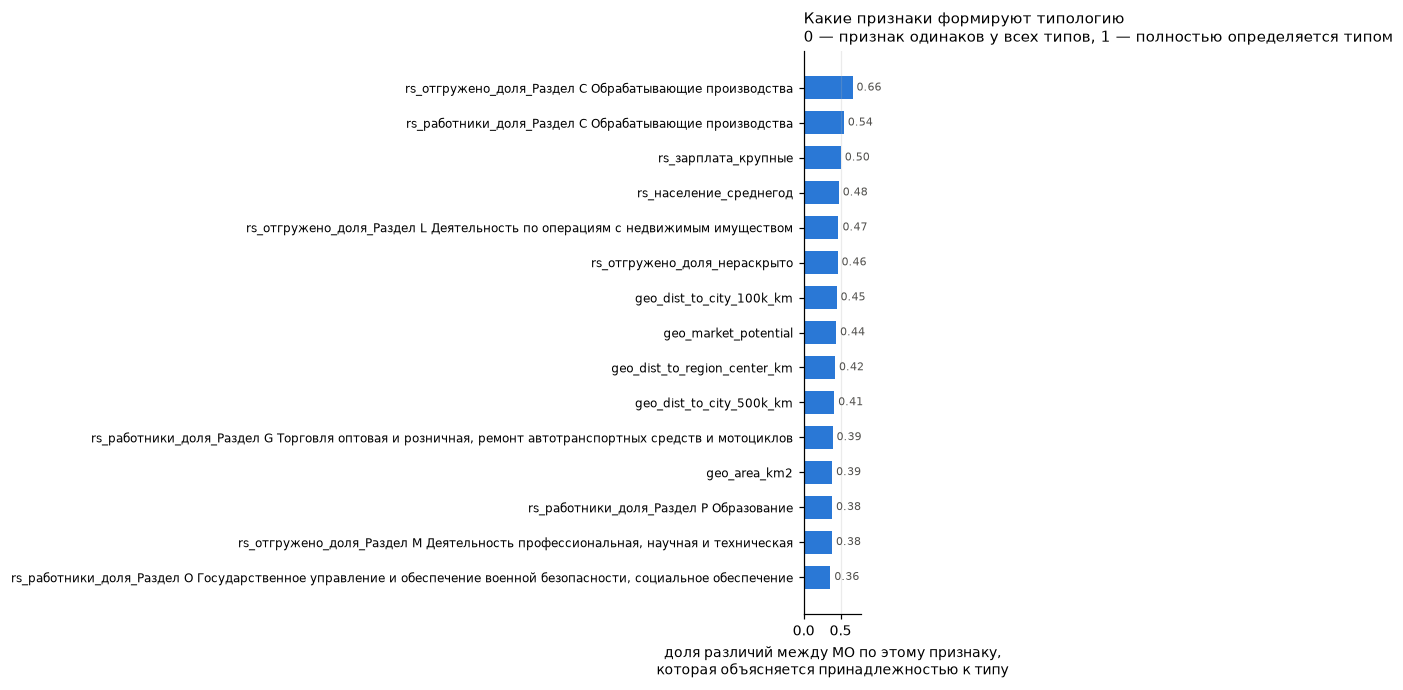

In [20]:
def plot_importance(importance, top=15):
    top_features = importance.head(top)[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.33 * len(top_features) + 1.4))
    ax.barh(range(len(top_features)), top_features.values, color=PALETTE[0], height=0.65)
    ax.set_yticks(range(len(top_features)), top_features.index, fontsize=8)
    for i, v in enumerate(top_features.values):
        ax.text(v, i, f' {v:.2f}', va='center', fontsize=7, color='#52514e')
    ax.set_xlim(0, max(top_features.max() * 1.18, 0.05))
    ax.set_xlabel('доля различий между МО по этому признаку,\nкоторая объясняется принадлежностью к типу')
    ax.set_title('Какие признаки формируют типологию\n'
                 '0 — признак одинаков у всех типов, 1 — полностью определяется типом',
                 fontsize=10, loc='left')
    ax.grid(axis='y', alpha=0)
    plt.tight_layout(); plt.show()


plot_importance(importance)

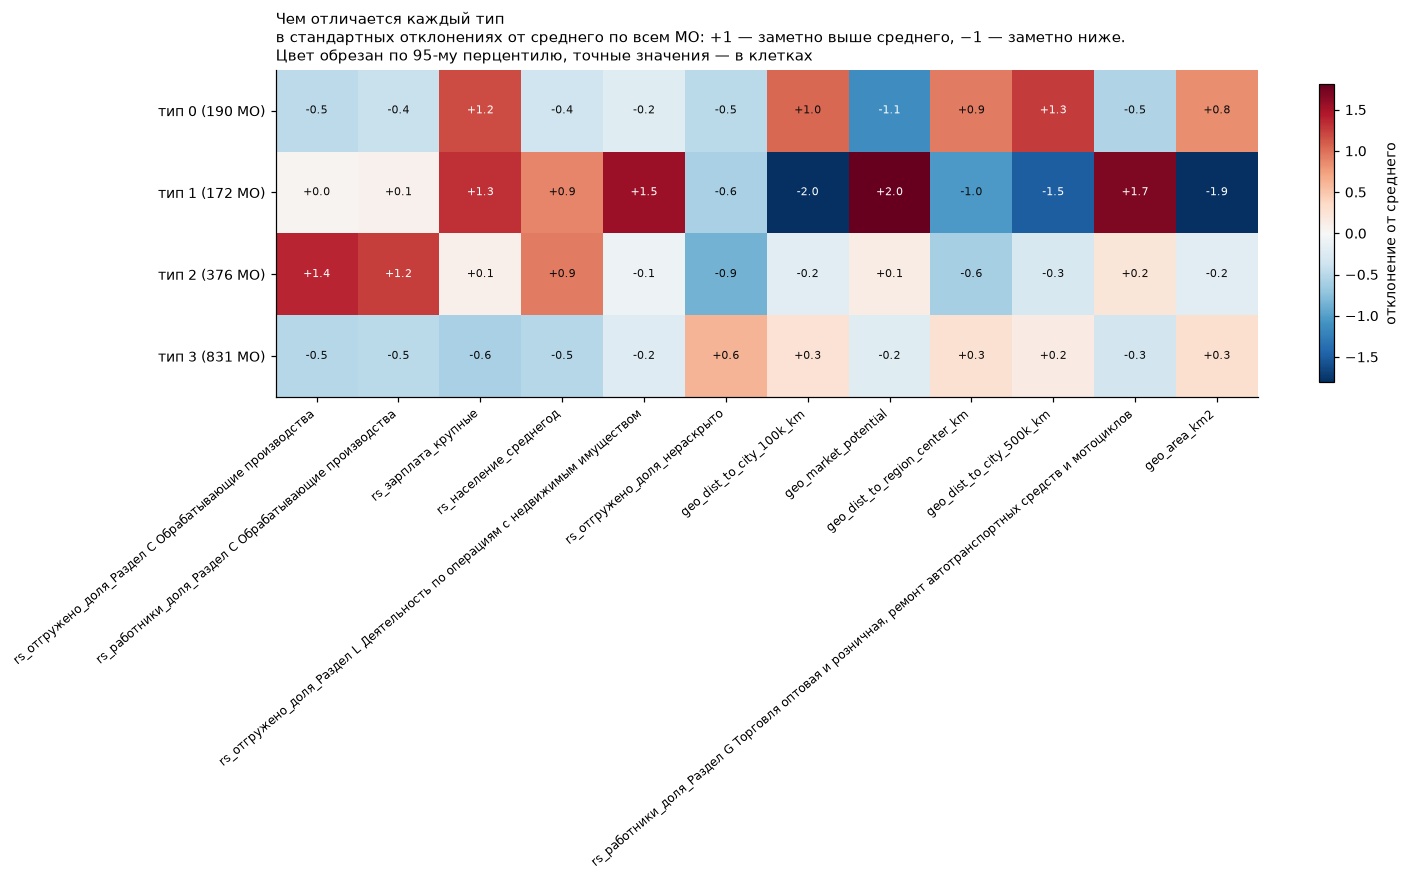

In [21]:
# Карта отличий: на сколько стандартных отклонений профиль типа
# отличается от среднего по всем МО
def profile_table(X, labels, order, top=12):
    keep = labels >= 0
    z = (X[keep] - X[keep].mean()) / X[keep].std()
    profile = z.groupby(labels[keep]).mean()
    return profile[order.head(top).index]


def plot_profile(profile, sizes):
    data = profile.values
    # Масштаб по 95-му перцентилю, а не по максимуму: одно экстремальное
    # значение иначе обесцвечивает всю остальную карту. Выходящие за шкалу
    # клетки читаются по числу
    limit = float(np.quantile(np.abs(data), 0.95)) or 1
    fig, ax = plt.subplots(figsize=(0.95 * data.shape[1] + 3, 0.5 * data.shape[0] + 2.4))
    # Расходящаяся шкала: синий — ниже среднего, белый — ровно среднее, красный — выше
    im = ax.imshow(data, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit))
    ax.set_xticks(range(data.shape[1]), profile.columns, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(data.shape[0]),
                  [f'тип {c} ({sizes[c]} МО)' for c in profile.index], fontsize=9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i, j]:+.1f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(data[i, j]) > 0.6 * limit else '#0b0b0b')
    ax.set_title('Чем отличается каждый тип\n'
                 'в стандартных отклонениях от среднего по всем МО: '
                 '+1 — заметно выше среднего, −1 — заметно ниже.\n'
                 'Цвет обрезан по 95-му перцентилю, точные значения — в клетках',
                 fontsize=10, loc='left')
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.8, label='отклонение от среднего')
    plt.tight_layout(); plt.show()


sizes = pd.Series(y_fit).value_counts().sort_index()
profile = profile_table(X_final, final_labels, importance)
plot_profile(profile, sizes)

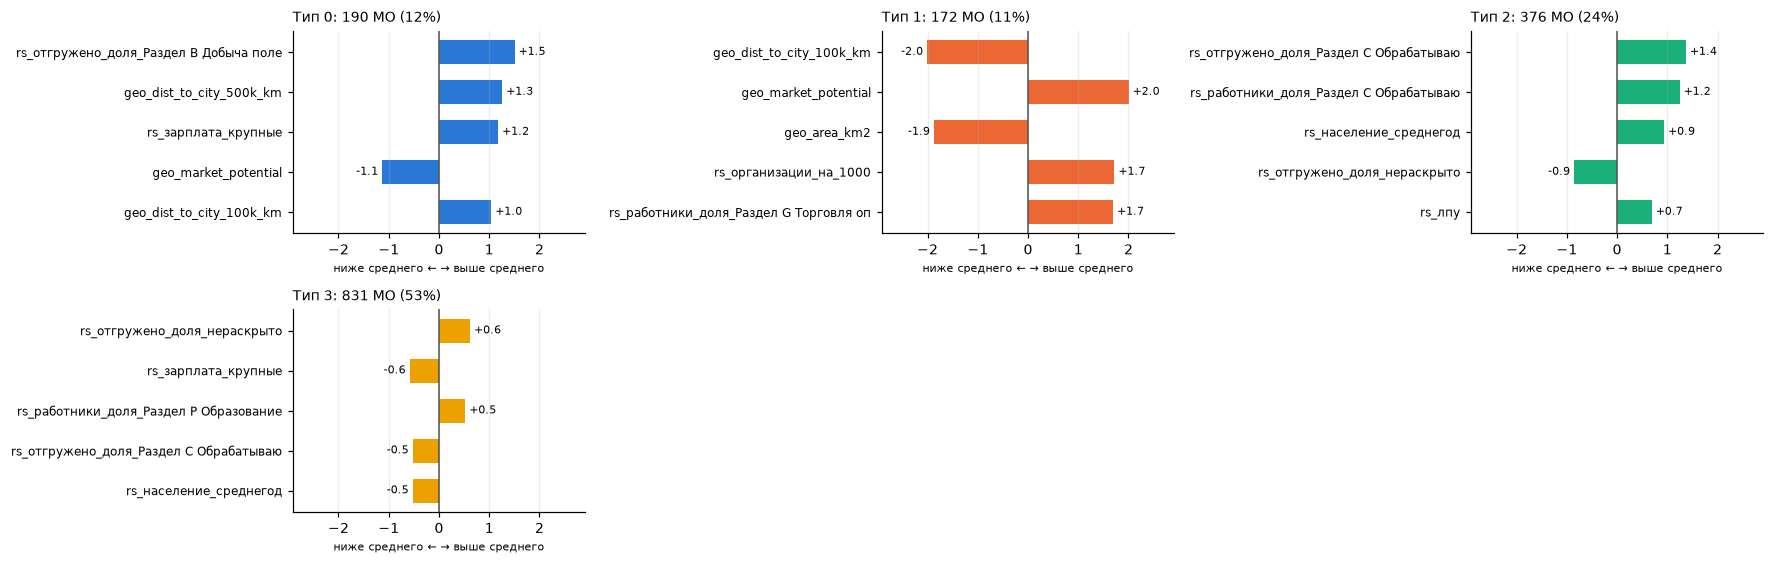

In [22]:
# Карточки типов: по пять главных отличий каждого
def plot_cards(profile_full, sizes, top=5):
    ids = list(profile_full.index)
    ncols = min(3, len(ids))
    nrows = int(np.ceil(len(ids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 2.6 * nrows), squeeze=False)
    # Общая шкала на всех карточках: иначе одинаковые по длине столбики
    # означают разные по величине отклонения, и типы не сравнить глазами
    shown = {c: profile_full.loc[c].reindex(
        profile_full.loc[c].abs().sort_values(ascending=False).index).head(top)[::-1]
        for c in ids}
    span = max(np.abs(r.values).max() for r in shown.values()) or 1
    for ax, (c, color) in zip(axes.ravel(), zip(ids, PALETTE * 3)):
        row = shown[c]
        ax.barh(range(len(row)), row.values, color=color, height=0.6)
        ax.axvline(0, color='#52514e', lw=1)
        ax.set_yticks(range(len(row)), [t[:38] for t in row.index], fontsize=8)
        ax.set_xlim(-span * 1.45, span * 1.45)
        for i, v in enumerate(row.values):
            ax.text(v, i, f' {v:+.1f} ', va='center', ha='left' if v >= 0 else 'right', fontsize=7)
        ax.set_title(f'Тип {c}: {sizes[c]} МО ({sizes[c] / sizes.sum():.0%})', fontsize=9, loc='left')
        ax.set_xlabel('ниже среднего ← → выше среднего', fontsize=7)
        ax.grid(axis='y', alpha=0)
    for ax in axes.ravel()[len(ids):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()


profile_full = profile_table(X_final, final_labels, importance, top=len(X_final.columns))
plot_cards(profile_full, sizes)

In [23]:
# Медоиды: типичные представители каждого типа. Узнаваемые названия —
# главная проверка того, что тип осмыслен
D_final = squareform(pdist(X_final.values))
names = features_raw.get('mo')
to_name = (lambda i: names.get(X_final.index[i], X_final.index[i])) if names is not None \
    else (lambda i: X_final.index[i])

rows = []
for c in sizes.index:
    idx = np.where(final_labels == c)[0]
    medoid = idx[D_final[np.ix_(idx, idx)].sum(axis=1).argmin()]
    nearest = idx[np.argsort(D_final[medoid, idx])[1:6]]
    rows.append({'тип': c, 'МО': sizes[c], 'медоид': to_name(medoid),
                 'ближайшие к медоиду': '; '.join(str(to_name(i)) for i in nearest)})
display(pd.DataFrame(rows).set_index('тип'))

,МО,медоид,ближайшие к медоиду
тип,,,
0,190,муниципальный район Сосногорск,муниципальный район Печора; Бавлинский муницип...
1,172,внутригородская территория города федерального...,внутригородская территория города федерального...
2,376,городской округ город Новомосковск,Щекинский муниципальный район; городской округ...
3,831,Усть-Калманский муниципальный район,Шипуновский муниципальный район; Кочковский му...


In [24]:
# Правила дерева: как отличить тип двумя-тремя условиями
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED).fit(X_tr, y_tr)
print(f'Точность дерева на отложенной выборке: {tree.score(X_te, y_te):.2f} '
      f'(высокая при глубине 3 означает, что типы различаются совсем просто)\n')
print(export_text(tree, feature_names=list(X_final.columns), decimals=2))

Точность дерева на отложенной выборке: 0.83 (высокая при глубине 3 означает, что типы различаются совсем просто)

|--- rs_отгружено_доля_Раздел C Обрабатывающие производства <= -0.63
|   |--- rs_зарплата_крупные <= 0.15
|   |   |--- rs_отгружено_доля_Раздел В Добыча полезных ископаемых <= 1.90
|   |   |   |--- class: 3
|   |   |--- rs_отгружено_доля_Раздел В Добыча полезных ископаемых >  1.90
|   |   |   |--- class: 3
|   |--- rs_зарплата_крупные >  0.15
|   |   |--- rs_отгружено_доля_нераскрыто <= 0.86
|   |   |   |--- class: 0
|   |   |--- rs_отгружено_доля_нераскрыто >  0.86
|   |   |   |--- class: 3
|--- rs_отгружено_доля_Раздел C Обрабатывающие производства >  -0.63
|   |--- geo_market_potential <= 1.37
|   |   |--- rs_работники_доля_Раздел C Обрабатывающие производства <= 0.14
|   |   |   |--- class: 0
|   |   |--- rs_работники_доля_Раздел C Обрабатывающие производства >  0.14
|   |   |   |--- class: 2
|   |--- geo_market_potential >  1.37
|   |   |--- geo_dist_to_city_100k_km <=

In [25]:
# Проверка: не свелась ли типология к шкале «крупный город — остальное».
# Смотрим, насколько признаки размера сами по себе объясняют разбиение.
size_like = [c for c in X_final.columns
             if any(w in c.lower() for w in ['населен', 'площад', 'уровень', 'pop', 'area', 'ntl_sum'])]
print('Признаки, связанные с размером:', size_like or 'не найдены')

if size_like:
    only_size = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_tr[size_like], y_tr)
    print(f'Точность только по размеру:  {only_size.score(X_te[size_like], y_te):.2f}')
    print(f'Точность по всем признакам:  {tree.score(X_te, y_te):.2f}')
    print('\nЧем ближе эти числа, тем сильнее типология повторяет шкалу '
          'размера города вместо устройства экономики')

# Проверка: выделились ли региональные центры сами.
# Флаг geo_is_region_center в признаки не подаётся — он почти совпадает
# с ответом. Зато по нему можно проверить результат: если центры собрались
# в один тип, значит их отличает экономика, а не наша подсказка
flag = features_raw.get('geo_is_region_center')
if flag is not None and flag.fillna(0).sum():
    flag = flag.reindex(X_fit.index).fillna(0).astype(int)
    by_type = pd.crosstab(y_fit, flag.values).reindex(columns=[0, 1], fill_value=0)
    by_type.columns = ['не центр', 'центр региона']
    by_type.index.name = 'тип'
    by_type['доля центров в типе'] = (by_type['центр региона'] / by_type.sum(axis=1)).round(3)
    display(by_type)
    main = by_type['центр региона'].idxmax()
    print(f'Больше всего центров в типе {main}: {by_type.loc[main, "центр региона"]} '
          f'из {int(flag.sum())}. Чем выше эта доля, тем лучше экономика '
          f'воспроизводит деление на центры без подсказки')


Признаки, связанные с размером: ['rs_население_среднегод', 'geo_area_km2']
Точность только по размеру:  0.76
Точность по всем признакам:  0.83

Если числа близки, типология повторяет шкалу размера города, а не описывает разные устройства экономики. Это нужно честно написать в выводах.


,не центр,центр региона,доля центров в типе
тип,,,
0,186,4,0.021
1,170,2,0.012
2,313,63,0.168
3,826,5,0.006


Больше всего центров в типе 2: 63 из 74. Чем выше эта доля, тем лучше экономика воспроизводит деление на центры без подсказки


### Названия типов

Название собирается из карточки типа и медоида: главное отличие плюс узнаваемый представитель. Для этого прогона:

| Тип | Название | На чём держится |
|---|---|---|
| 0 | сырьевые районы | высокая доля добычи в отгрузке, далеко от крупных городов |
| 1 | ядра агломераций | рынок рядом, высокий потенциал; медоиды — внутригородские территории Москвы и Петербурга |
| 2 | промышленные города | высокая доля обрабатывающих производств в отгрузке и в занятости |
| 3 | аграрная периферия | низкие зарплаты, отгрузка почти целиком под грифом конфиденциальности |

Если число типов в прогоне изменится, словарь `TYPE_NAMES` перестанет совпадать с разбиением и в таблице останутся черновые названия, собранные автоматически.


In [26]:
def auto_name(row, top=2):
    strong = row.reindex(row.abs().sort_values(ascending=False).index).head(top)
    parts = [f'{"высокая" if v > 0 else "низкая"} {name}' for name, v in strong.items()]
    return '; '.join(parts)


names_by_cluster = {c: auto_name(profile_full.loc[c]) for c in sizes.index}
summary_types = pd.DataFrame({'МО': sizes, 'доля': (sizes / sizes.sum()).round(3),
                              'черновое название': pd.Series(names_by_cluster)})
display(summary_types)

TYPE_NAMES = {0: 'сырьевые районы', 1: 'ядра агломераций',
              2: 'промышленные города', 3: 'аграрная периферия'}

# Чистовые названия применяются, только если словарь совпал с разбиением:
# иначе прогон дал другое число типов и нумерация сдвинулась
if set(TYPE_NAMES) == set(sizes.index):
    names_by_cluster = dict(TYPE_NAMES)
    display(pd.DataFrame({'МО': sizes, 'доля': (sizes / sizes.sum()).round(3),
                          'тип экономики': pd.Series(names_by_cluster)}))
else:
    print('TYPE_NAMES не совпадает с разбиением, остаются черновые названия')

,МО,доля,черновое название
0,190,0.121,высокая rs_отгружено_доля_Раздел В Добыча поле...
1,172,0.110,низкая geo_dist_to_city_100k_km; высокая geo_m...
2,376,0.240,высокая rs_отгружено_доля_Раздел C Обрабатываю...
3,831,0.530,высокая rs_отгружено_доля_нераскрыто; низкая r...


## 11. Динамика во времени

Повторяем итоговую кластеризацию в скользящем окне по 12 месяцев, сопоставляем кластеры соседних окон и смотрим, кто меняет тип. Раздел короткий: при 24 месяцах получается 13 окон, большего эти данные не выдерживают.

Признаки из статики в окнах не меняются, поэтому динамика считается только по рядам: окно влияет лишь на ту часть расстояния, которая зависит от трат.

In [27]:
from scipy.optimize import linear_sum_assignment

WINDOW, STEP, LAMBDA = 12, 1, 0.5


def align(prev, new):
    # Перенумеровать кластеры нового окна так, чтобы они совпали с предыдущим
    a, b = np.unique(prev), np.unique(new)
    overlap = np.array([[np.sum((prev == x) & (new == y)) for y in b] for x in a])
    rows, cols = linear_sum_assignment(-overlap)
    mapping = {b[c]: a[r] for r, c in zip(rows, cols) if overlap[r, c] > 0}
    extra = max(prev.max(), new.max()) + 1
    for y in b:
        if y not in mapping:
            mapping[y] = extra; extra += 1
    return np.array([mapping[y] for y in new])


# k-means и Ward работают с таблицей признаков, а не с матрицей расстояний,
# поэтому окно на них не влияет — во всех окнах вышло бы одно и то же разбиение,
# а ARI оказался бы равен единице независимо от данных. Для динамики берём
# метод, который действительно считает по расстояниям
DISTANCE_BASED = {'kmedoids', 'spectral', 'louvain', 'hdbscan'}
method, param = final_row['метод'], final_row['параметр']
if method not in DISTANCE_BASED:
    param = int(final_row['k_факт'])
    print(f'Итоговый метод {method} не зависит от матрицы расстояний, '
          f'для динамики используется kmedoids с тем же числом кластеров ({param})')
    method = 'kmedoids'

window_ends, labels_t, prev = [], [], None
for s in range(0, X_ts_common.shape[1] - WINDOW + 1, STEP):
    D_win = correlation_distance(X_ts_common[:, s:s + WINDOW], pd.Index(common)).values
    D_mix = (1 - LAMBDA) * D_attr_norm + LAMBDA * D_win / (D_win.max() or 1)
    labels = run_method(method, param, D_mix, X_static_common.values)
    labels = align(prev, labels) if prev is not None else labels
    prev = labels
    labels_t.append(labels)
    window_ends.append(periods[s + WINDOW - 1].strftime('%Y-%m'))

labels_t = np.array(labels_t)
ari_steps = [adjusted_rand_score(labels_t[i], labels_t[i + 1]) for i in range(len(labels_t) - 1)]
stable_share = (labels_t[1:] == labels_t[:-1]).mean()
print(f'Окон: {len(window_ends)} ({window_ends[0]} … {window_ends[-1]})')
print(f'Согласованность соседних окон (ARI): {np.mean(ari_steps):.2f}')
print(f'Доля переходов без смены типа: {stable_share:.2f}')

Итоговый метод kmeans не зависит от матрицы расстояний, для динамики используется kmedoids с тем же числом кластеров (4)
Окон: 13 (2023-12 … 2024-12)
Согласованность соседних окон (ARI): 0.37
Доля переходов без смены типа: 0.61


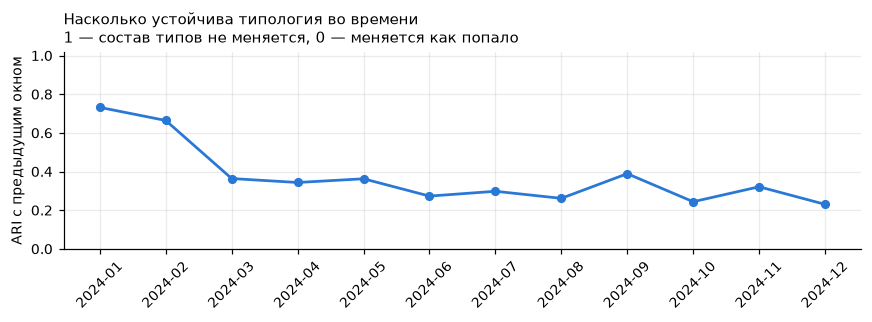

Вероятности смены типа за один шаг окна:


в тип,0,1,2,3,4
из типа,,,,,
0,0.696,0.250,0.036,0.018,0.000
1,0.009,0.688,0.216,0.062,0.025
2,0.004,0.195,0.482,0.194,0.125
3,0.001,0.027,0.114,0.637,0.220
4,0.000,0.039,0.097,0.317,0.547


In [28]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(window_ends[1:], ari_steps, color=PALETTE[0], lw=1.8, marker='o', ms=5)
ax.set_ylim(0, 1.02)
ax.set_ylabel('ARI с предыдущим окном')
ax.set_title('Насколько устойчива типология во времени\n'
             '1 — состав типов не меняется, 0 — меняется как попало', fontsize=10, loc='left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

transitions = pd.crosstab(labels_t[:-1].ravel(), labels_t[1:].ravel(),
                          rownames=['из типа'], colnames=['в тип'], normalize='index')
print('Вероятности смены типа за один шаг окна:')
display(transitions.round(3))

## 12. Выводы и экспорт

In [29]:
print(f'''
Данных:        {len(X_final)} МО, {X_final.shape[1]} признаков после отбора
Прогонов:      A (статика) и B1 (статика + ряды), плюс сетка λ в B2
Итог:          прогон {source}, метод {final_row['метод']}, параметр {final_row['параметр']:g}
Типов:         {len(sizes)}; размеры: {', '.join(map(str, sizes.values))}
Индексы:       SW={final_row['SW']:.3f}  CH={final_row['CH']:.0f}  '''
      f'''S_Dbw={final_row['S_Dbw']:.3f}  MQ={final_row['MQ']:.3f}
Устойчивость:  ARI={final_row['устойчивость']:.2f} на подвыборках 80%
Динамика:      {len(window_ends)} окон по {WINDOW} мес., ARI соседних окон {np.mean(ari_steps):.2f}
''')
for c in sizes.index:
    print(f'  Тип {c} ({sizes[c]} МО): {names_by_cluster[c]}')


Данных:        1569 МО, 52 признаков после отбора
Прогонов:      A (статика) и B1 (статика + ряды), плюс сетка λ в B2
Итог:          прогон A: только статика, метод kmeans, параметр 4
Типов:         4; размеры: 190, 172, 376, 831
Индексы:       SW=0.121  CH=156  S_Dbw=1.384  MQ=0.468
Устойчивость:  ARI=0.96 на подвыборках 80%
Динамика:      13 окон по 12 мес., ARI соседних окон 0.37

  Тип 0 (190 МО): высокая rs_отгружено_доля_Раздел В Добыча полезных ископаемых; высокая geo_dist_to_city_500k_km
  Тип 1 (172 МО): низкая geo_dist_to_city_100k_km; высокая geo_market_potential
  Тип 2 (376 МО): высокая rs_отгружено_доля_Раздел C Обрабатывающие производства; высокая rs_работники_доля_Раздел C Обрабатывающие производства
  Тип 3 (831 МО): высокая rs_отгружено_доля_нераскрыто; низкая rs_зарплата_крупные


**Ограничения**

* Лаг Росстата: у части показателей свежие данные отстают на год или два.
* Пропуски по конфиденциальности у малых МО: редкие заполнены медианой, что сглаживает различия; МО с заполненностью ниже половины признаков из анализа исключены.
* Ряд трат короткий, 24 месяца, поэтому в динамике всего 13 окон.
* Сопоставление трат с границами идёт по сокращённому названию МО, и неоднозначные названия (два Александровских района в разных регионах) отбрасываются.


## 13. Разбор результатов

1569 МО, 52 признака, 4 типа (k-means, k = 4). Разбиение рабочее.

### Типы

| Тип | МО | Медоид и ближайшие к нему | На чём держится |
|---|---|---|---|
| 0 | 190 | Сосногорск, Печора, Бавлинский район | добыча в отгрузке, далеко от крупных городов |
| 1 | 172 | внутригородские территории Москвы и Петербурга | рынок рядом, высокий потенциал рынка |
| 2 | 376 | Новомосковск, Щёкинский район | обрабатывающие производства в отгрузке и в занятости |
| 3 | 831 | Усть-Калманский, Шипуновский, Кочковский районы | низкие зарплаты, отгрузка под грифом конфиденциальности |

Сырьё, агломерации, обработка, село — четыре разных устройства экономики, каждое со своим механизмом. Медоиды узнаваемы. Лес различает типы на отложенной выборке с точностью 0.93 при случайном угадывании 0.25, дерево глубины 3 — 0.83, устойчивость 0.96 на подвыборках 80%.

Сильнее всего типы различает доля обрабатывающих производств: она объясняет 0.662 различий по отгрузке и 0.544 по занятости. Дальше идут зарплата (0.504), население (0.475), доля операций с недвижимостью (0.472) и доля нераскрытой отгрузки (0.460).

### Региональные центры не образовали отдельного типа

Флаг «центр региона» из признаков исключён: он почти совпадает с ответом и сам задавал бы один из типов. Проверка показала, где центры оказались без подсказки — 63 из 74 попали в промышленные города, где составляют 17% состава.

Содержательный вывод: по экономике региональные центры близки к крупным промышленным городам и в отдельную группу не выделяются. Деление на центры и нецентры задаётся административным статусом, в структуре отгрузки и занятости оно не читается.

### Низкий силуэт при высокой устойчивости

SW = 0.121 при устойчивости 0.96. Разбиение воспроизводится почти полностью при выбрасывании пятой части МО, но резких границ между типами в данных нет: экономики МО переходят друг в друга непрерывно, и промежуточных МО много. Низкий силуэт здесь описывает форму облака точек; о качестве работы метода говорит устойчивость.

Отсюда следует, как пользоваться индексами в этой задаче. SW, CH и S_Dbw чувствительны к тому, не перетянул ли один признак на себя всё расстояние: при таком перекосе они дружно показывают отличное качество. Для выбора между содержательно разными разбиениями надёжнее устойчивость и модулярность MQ.

### Сравнение методов

Четыре метода из шести дали невырожденные разбиения. k-means и Ward сошлись на одном и том же k = 4 с близкими индексами, k-medoids выбрал k = 6 при устойчивости 0.39.

Отдельно стоит Louvain: он нашёл в сети 11 сообществ с модулярностью 0.757 против 0.468 у итогового разбиения, то есть в структуре связей есть деление мельче четырёх типов. Устойчивость у него 0.65, и по сумме мест он уступает. Разумное чтение этих двух чисел: четыре типа — верхний уровень, под ним существует более дробная структура, но на этом наборе признаков она воспроизводится хуже.

HDBSCAN вырожден при всех настройках. На этих данных нет областей достаточно разной плотности, чтобы выделить сгущения и отделить их от фона — то же самое, о чём говорит низкий силуэт.

### Траты не добавили к статике

Прогон B1 (статика плюс признаки рядов) дал лучший результат на k = 2 с устойчивостью 0.942 против 0.957 у прогона A, то есть деление пополам. В сетке λ устойчивость падает монотонно по мере роста веса рядов: 0.952 при λ = 0, затем 0.785, 0.664, 0.574, 0.588. ARI с λ = 0 падает до 0.15–0.33: ряды меняют состав групп сильно, и воспроизводимость при этом только ухудшается.

Вывод: помесячная структура потребительских трат почти не несёт информации о типе локальной экономики сверх той, что уже есть в отраслевой структуре и демографии. Правдоподобная причина — пять категорий трат сильно сглажены: доля продовольствия у половины МО лежит около 0.62 при разбросе от 0.4 до 0.8, и такого разброса не хватает, чтобы разделить 1569 МО.

### Что ограничивает результат

**Тип 3 — 831 МО, 53% выборки — описан через долю нераскрытой отгрузки.** Этот признак описывает режим публикации данных: Росстат скрывает значение, когда в МО слишком мало предприятий. Для аграрной периферии признак работает как прокси ровно по этой причине. Но структура внутри самого большого типа остаётся нераскрытой, и разделить его на этих данных нечем.

**Проверка на размер прошла с небольшим запасом:** 0.76 только по признакам размера против 0.83 по всем признакам. Разрыв 0.07 означает, что размер МО объясняет большую часть разбиения. Содержательно это ожидаемо — крупные города и сельские районы действительно устроены по-разному, — но различие между типами 0 и 2 (добыча и обработка) размером не объясняется, и именно оно даёт типологии содержание сверх шкалы.

### Сеть

Сеть строится до кластеризации и от числа типов не зависит: 1569 узлов, 5232 ребра при k = 15, один компонент, изолированных МО нет. Взаимные kNN сами по себе рассыпают граф — при k = 15 остаются 94 компоненты и 75 МО без рёбер, — поэтому к ним добавляется минимальное остовное дерево, которое связывает граф, добавляя 295 рёбер из 5232.

Модулярность итогового разбиения MQ = 0.468: почти половина веса рёбер идёт внутри типов при четырёх группах. Структура, найденная в пространстве признаков, видна и в структуре связей.

### Динамика

13 окон по 12 месяцев, ARI между соседними окнами 0.37, диагональ матрицы переходов от 0.48 до 0.70. Сопоставление соседних окон венгерским алгоритмом создало пятый идентификатор на четыре типа: в части окон появляется группа, которой в итоговом разбиении нет.

Окна перекрываются на 11 месяцев из 12, то есть соседние окна различаются одним месяцем. Смена типа при таком сдвиге говорит скорее о сезонных колебаниях категорий, чем о переходе экономики в другое состояние. Это согласуется с результатом прогона B: траты слабо связаны с типом, поэтому и типология по окнам неустойчива.

### Что не вошло

Растровые признаки (`collect_rasters.ipynb`) в этот прогон не включены. Признаки OSM (`osm_features.ipynb`) тоже: их полнота неравномерна между городом и селом и создала бы артефакт в пользу городов.


In [30]:
result = pd.DataFrame({'кластер': final_labels}, index=X_final.index)
result['название'] = result['кластер'].map(names_by_cluster)
if names is not None:
    result.insert(0, 'мо', names.reindex(result.index))
result.to_csv(OUT / 'clusters.csv')

pd.DataFrame(labels_t.T, index=common, columns=window_ends).to_csv(OUT / 'clusters_by_window.csv')
profile_full.to_csv(OUT / 'cluster_profiles.csv')
importance.to_frame('важность').to_csv(OUT / 'feature_importance.csv')

i, j = np.nonzero(np.triu(knn_graph(D_final), k=1))
pd.DataFrame({'source': X_final.index[i], 'target': X_final.index[j],
              'weight': knn_graph(D_final)[i, j]}).to_csv(OUT / 'network_edges.csv', index=False)
print('Сохранено:', [p.name for p in sorted(OUT.glob('*.csv'))])

Сохранено: ['cluster_profiles.csv', 'clusters.csv', 'clusters_by_window.csv', 'feature_importance.csv', 'mo_features.csv', 'network_edges.csv']
